# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
G = 6.67e-11 #gravitational constant in m^3/kg/s^2
g = 9.81 #gravitational acceleration in m/s^2
M_E = 5.9e24 #mass of the earth in kg
M_M = 7.3e22 #mass of the moon in kg
M_A = 5500.0 #mass of the apollo command module in kg
R_E = 6378.0 #radius of the earth in km
R_M = 1737.0 #radius of the moon in km
d_EM = 3.8e8 #distance fo the earth to the moon in m 
v_e = 2.4e3 #exhuast velocity of saturn v stage 1 (S-1C) in m/s
m_dot = 1.3e4 #burn rate of S1-C in kg/s
m_0 = 2.8e6 #wet mass of S-1C in kg
m_f = 7.5e5 #dry mass of S1-C in kg

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
def grav_pot(M: float, x_m: float,y_m: float, x: float or np.array, y: float or np.array) -> (float, np.ndarray):
    
    """ The "grav_pot" function calculates the gravitational potential at a given distance away from a physical body of mass M
    -------
    Args:

    M (float): The mass of the physical body in kilograms
    x_m (float): The cartesian x-coordinate of the position of the body in meters
    y_m (float): The cartesian y-coordinate of the position of the body in meters
    x (float): The cartesian x-coordinate of the point the potential is evaluated at in meters
    y (float): The cartesian y-coordinate of the point the potential is evaluated at in meters

    Returns: 

    phi (float): The gravitational potential at point (x,y) from body of mass M located at (x_m,y_m) in joules per kilogram

    Preconditions:
        * Mass, x_m, and y_m arguments must be floats
        * The mass argument 'M' cannot be zero or less than zero
    Postconditions:
        * Phi cannot be returned as a string
    """
    if not isinstance (M, float):
        raise TypeError(f"Input {M} is of the wrong type.")
    elif not isinstance (x_m, float):
        raise TypeError(f"Input {x_m} is of the wrong type.")
    elif not isinstance (y_m, float):
        raise TypeError(f"Input {y_m} is of the wrong type.")
    elif not isinstance (x, (float,np.ndarray)):
        raise TypeError(f"Input {x} is of the wrong type.")
    elif not isinstance (y, (float,np.ndarray)):
        raise TypeError(f"Input {y} is of the wrong type.")
    elif M <= 0:
        raise ValueError(f"Mass cannot be zero or less than zero")
    else:
        r=np.sqrt((((x-x_m)**2)) + ((y-y_m)**2))
        phi = -(G*M)/r
        assert (phi != str).any(), "Potential cannot be a string"
    return np.where(np.isclose(r,0), np.nan, phi)

2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

Graph begins at -570000000.0 meters and ends at 570000000.0 meters, which are 1.5 times the distance from the Earth to the Moon in either direction


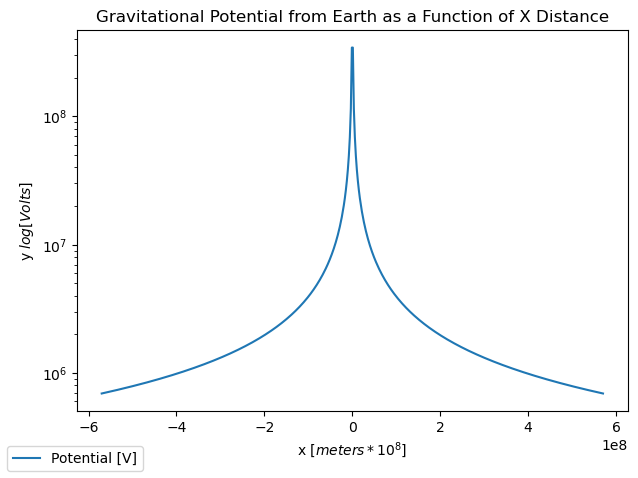

In [4]:
dis = d_EM * 1.5
print(f"Graph begins at {-dis} meters and ends at {dis} meters, which are 1.5 times the distance from the Earth to the Moon in either direction")
x1 = np.linspace(-dis, dis, 500)
y1 = np.abs(grav_pot(M_E, 0.0, 0.0, x1, 0.0))
fig, ax = plt.subplots()
ax.plot(x1,y1, label='Potential [V]')
ax.set_yscale('log')
ax.set_xlabel('x $[meters * 10^8]$')
ax.set_ylabel('y $log[Volts]$')
ax.set_title('Gravitational Potential from Earth as a Function of X Distance')
fig.legend(loc=3)
plt.tight_layout()

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

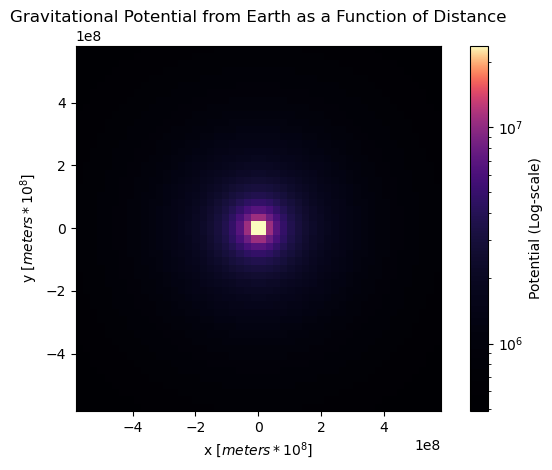

In [5]:
x2 = np.linspace(-dis, dis, 50)
y2 = np.linspace(-dis, dis, 50)
x_grid, y_grid = np.meshgrid(x2,y2)
pot = np.abs(grav_pot(M_E, 0.0, 0.0, x_grid,y_grid))
fig, ax = plt.subplots()
ax.set_title('Gravitational Potential from Earth as a Function of Distance')
ax.set_aspect("equal")
ax.set_xlabel('x $[meters * 10^8]$')
ax.set_ylabel('y $[meters * 10^8]$')
mesh = ax.pcolormesh(x_grid,y_grid,pot, cmap="magma")
cbar = fig.colorbar(mesh)
cbar.ax.set_yscale('log')
cbar.set_label("Potential (Log-scale)")
plt.tight_layout()

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

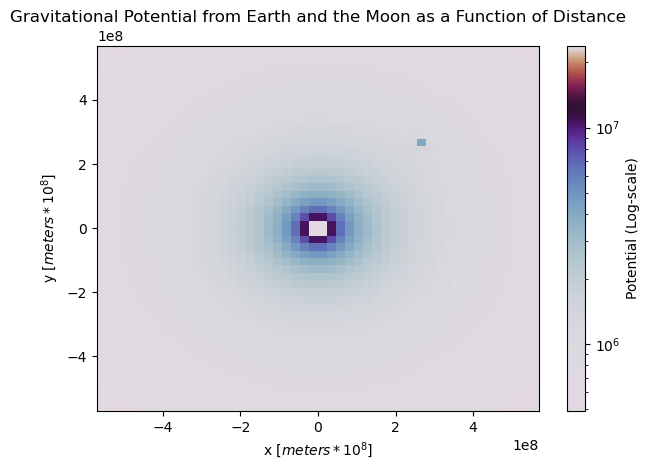

In [6]:
x_m = d_EM / np.sqrt(2)
y_m = d_EM / np.sqrt(2)
earth_pot = grav_pot(M_E,0.0,0.0,x_grid,y_grid)
moon_pot = grav_pot(M_M, x_m, y_m, x_grid,y_grid)
total_pot = earth_pot + moon_pot # scalar values so you can add them
abs_total_pot = np.abs(total_pot)
x_grid, y_grid = np.meshgrid(x2,y2)
fig, ax = plt.subplots()
ax.set_xlim(-dis,dis)
ax.set_ylim(-dis,dis)
ax.set_title('Gravitational Potential from Earth and the Moon as a Function of Distance')
ax.set_xlabel('x $[meters * 10^8]$')
ax.set_ylabel('y $[meters * 10^8]$')
mesh2 = ax.pcolormesh(x_grid, y_grid, abs_total_pot, cmap='twilight')
cbar = fig.colorbar(mesh2)
cbar.ax.set_yscale('log')
cbar.set_label("Potential (Log-scale)")
plt.tight_layout()
#note the singularity in the middle

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

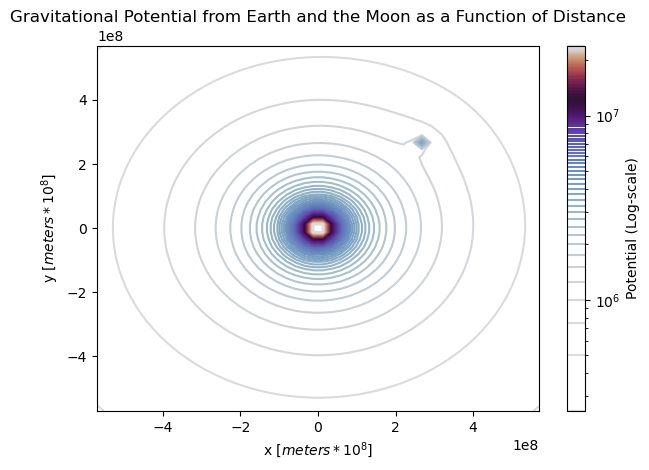

In [7]:
fig, ax = plt.subplots()
ax.set_xlim(-dis,dis)
ax.set_ylim(-dis,dis)
ax.set_title('Gravitational Potential from Earth and the Moon as a Function of Distance')
ax.set_xlabel('x $[meters * 10^8]$')
ax.set_ylabel('y $[meters * 10^8]$')
contour = ax.contour(x_grid, y_grid, abs_total_pot, cmap='twilight', levels=100)
cbar = fig.colorbar(contour)
cbar.ax.set_yscale('log')
cbar.set_label("Potential (Log-scale)")
plt.tight_layout()

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def grav_force(M1:float , m2:float, x1:float, y1:float, x2:float or np.ndarray, y2:float or np.ndarray) -> (float, np.ndarray):
    """ The "grav_pot" function calculates the gravitational potential at a given distance away from a physical body of mass M
    -------
    Args:

    M1 (float): The mass of the FIRST physical body in kilograms
    m2 (float): The mass of the SECOND physical body in kilograms
    x1 (float): The cartesian x-coordinate of the position of the FIRST body in meters
    y1 (float): The cartesian y-coordinate of the position of the FIRST body in meters 
    x2 (float or np.ndarray): The cartesian x-coordinate of the position of the SECOND body in meters
    y2 (float or np.ndarray): The cartesian y-coordinate of the position of the SECOND body in meters 

    Returns: 

    Fx (float or np.ndarray): The x-component of gravitational force experience by body of mass m2 at point (x2,y2) from body of mass M1 located at (x1,y1) in Newtons
    Fy (float or np.ndarray): The y-component of gravitational force experience by body of mass m2 at point (x2,y2) from body of mass M1 located at (x1,y1) in Newtons
    
    Preconditions:
        * M1, m2, x1 and y1 arguments must be floats
        * The mass arguments 'M1' and 'm2' cannot be zero or less than zero
    Postconditions:
        * Fx and Fy cannot be strings
    """
    if np.isclose(x2,x1) and np.isclose(y2,y1):
        Fx = np.nan
        Fy = np.nan
    if not isinstance (M1, float):
        raise TypeError(f"Input {M1} is of the wrong type.")
    elif not isinstance (m2, float):
        raise TypeError(f"Input {m2} is of the wrong type.")
    elif not isinstance (x1, float):
        raise TypeError(f"Input {x1} is of the wrong type.")
    elif not isinstance (y1, float):
        raise TypeError(f"Input {y1} is of the wrong type.")
    elif not isinstance (x2, (float, np.ndarray)):
        raise TypeError(f"Input {x2} is of the wrong type.")
    elif not isinstance (y2, (float, np.ndarray)):
        raise TypeError(f"Input {y2} is of the wrong type.")
    elif M1 <= 0:
        raise ValueError(f"Mass cannot be zero or less than zero")
    elif m2 <= 0:
        raise ValueError(f"Mass cannot be zero or less than zero")
    else:
        r_squared = np.abs(np.hypot(x2-x1,y2-y1))**2
        vec_r = np.array([x2-x1, y2-y1])
        vec_r_hat = vec_r/np.linalg.norm(vec_r)
        Fx = (-G * (M1*m2)/(r_squared)) * vec_r_hat[0] #x
        Fy = (-G * (M1*m2)/(r_squared)) * vec_r_hat[1] #y

    assert Fx != str, "Force cannot be a string"
    assert Fy != str, "Force cannot be a string"
    
    return np.where(np.isclose(r_squared,0), np.nan, (Fx, Fy))

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

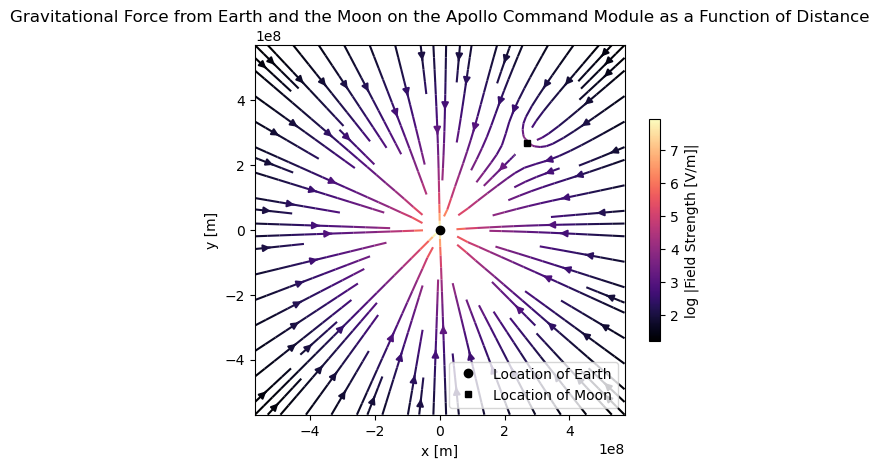

In [14]:
ny = 30
nx = 30
y = np.linspace(-dis,dis,ny)
x = np.linspace(-dis,dis,nx)
x_grid, y_grid = np.meshgrid(x,y)
fx = np.zeros((ny,nx))
fy = np.zeros((ny,nx))

for y in range(ny):
    for x in range (nx): 
        #compute g field of earth
        F_Earth_x, F_Earth_y = grav_force(M_E, M_A, 0.0, 0.0, x_grid[y,x], y_grid[y,x])
        # compute g field of moon
        F_Moon_x, F_Moon_y = grav_force(M_M, M_A, x_m, y_m, x_grid[y,x], y_grid[y,x])
        #sum them
        fx[y,x] += (F_Earth_x + F_Moon_x)
        fy[y,x] += (F_Earth_y + F_Moon_y)
        
fig, ax = plt.subplots()
colors = np.log(np.hypot(fx,fy))
stream = ax.streamplot(x_grid,y_grid, fx, fy, color=colors, cmap="magma")
ax.plot(0,0,'ko', label="Location of Earth")
ax.plot(x_m,y_m,'ks', markersize=4, label="Location of Moon")
ax.set_aspect("equal")
ax.set_title('Gravitational Force from Earth and the Moon on the Apollo Command Module as a Function of Distance')
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.legend(loc=4)
cbar = fig.colorbar(stream.lines, shrink = 0.6) 
cbar.set_label("log |Field Strength [V/m]|")

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

$$|\vec{F}_{moon}| = |\vec{F}_{earth}|$$
$$\vec{F}_{Moon} = -G \frac{M_{moon} m_{apollo}}{|\vec{r1}_{distance}|^2}$$
$$\vec{F}_{Earth} = -G \frac{M_{Earth} m_{apollo}}{|\vec{r2}_{distance}|^2}$$
$$ -G \frac{M_{moon} m_{apollo}}{|\vec{r1}_{distance}|^2} = -G \frac{M_{Earth} m_{apollo}}{|\vec{r2}_{distance}|^2}$$
$$\frac{M_{moon}}{{|\vec{r1}_{distance}|^2}} = \frac{M_{earth}}{{|\vec{r2}_{distance}|^2}}$$
$$\frac{M_{moon}}{{|(x-\frac{d}{\sqrt{2}})^2+ (y-\frac{d}{\sqrt{2}})^2|}} = \frac{M_{earth}}{{|x^2+y^2|}}$$
Since both forces must be equal and it's on the line between Earth and the Moon, which is on a 45 degree angle, $y = x$ can be used as a substitution.
So,
$$\frac{M_{moon}}{{|2(x-\frac{d}{\sqrt{2}})^2|}} = \frac{M_{earth}}{{|2x^2|}}$$
$$\frac{M_{moon}}{{|(x-\frac{d}{\sqrt{2}})^2|}} = \frac{M_{earth}}{{|x^2|}}$$
$$\frac{\sqrt{M_{moon}}}{{|(x-\frac{d}{\sqrt{2}})|}} = \frac{\sqrt{M_{earth}}}{|x|}$$
$$\sqrt{M_{moon}}(|x|) = \sqrt{M_{earth}}(|x-\frac{d}{\sqrt{2}}|)$$
$${x} = \frac{d/{\sqrt{2}}}{1+{\sqrt{{M}_{moon}/{M}_{earth}}}}$$
$${y} = \frac{d/{\sqrt{2}}}{1+{\sqrt{{M}_{moon}/{M}_{earth}}}}$$
$$(x,y) = (\frac{d/{\sqrt{2}}}{1+{\sqrt{{M}_{moon}/{M}_{earth}}}}, \frac{d/{\sqrt{2}}}{1+{\sqrt{{M}_{moon}/{M}_{earth}}}})$$

And your updated plot, including the balance point, goes in the cell below.

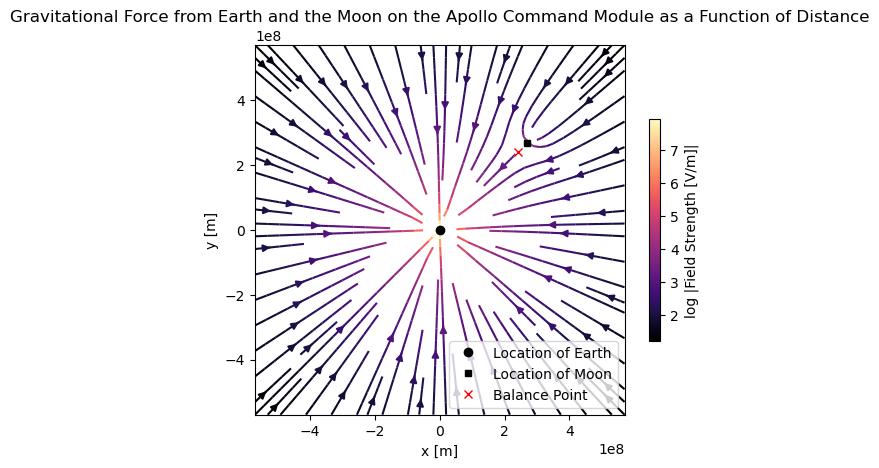

In [10]:
x_balance = x_m / (1+np.sqrt(M_M/M_E))
y_balance = y_m / (1+np.sqrt(M_M/M_E))

fig, ax = plt.subplots()
colors = np.log(np.hypot(fx,fy))
stream = ax.streamplot(x_grid,y_grid, fx, fy, color=colors, cmap="magma")
ax.plot(0,0,'ko',label='Location of Earth')
ax.plot(x_m,y_m,'ks', markersize=4, label='Location of Moon')
ax.plot(x_balance,y_balance,'rx', label='Balance Point')
ax.set_aspect("equal")
ax.set_title('Gravitational Force from Earth and the Moon on the Apollo Command Module as a Function of Distance')
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
cbar = fig.colorbar(stream.lines, shrink = 0.6) 
cbar.set_label("log |Field Strength [V/m]|")
ax.legend(loc=4)

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

The balance point is closer to the Moon than to the Earth. This makes sense because gravitational force is proportional to: $$\frac{1}{r^2}$$ Because the mass of the Earth is so much larger than the mass of the moon, the radius squared in the denominator of the moon expression must be very small in order to make the entire moon expression bigger, which would help to make it equal to the Earth expression.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [11]:
T = (m_0 - m_f)/ m_dot
print(f'The burn time T for the first stage of the new Saturn V rocket is {T} seconds')

The burn time T for the first stage of the new Saturn V rocket is 157.69230769230768 seconds


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
**Note that the rocket eventually runs out of fuel**,
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [12]:
def velocity(t:float, m0:float, mf:float, mdot:float, ve:float, grav_constant:float) -> float:
    """ The "velocity" function calculates the change in velocity of a rocket under a set of simplifying assumptions using the Tsiolkovsky rocket equation
    -------
    Args:

    t (float): The time at which the change in velocity of the rocket is to be calculated in seconds
    m0 (float): The wet mass of the rocket in kilograms
    mf (float): The dry mass of the rocket in kilograms
    mdot (float): The constant fuel burn rate of the rocket in kilograms per second
    ve (float): The exhaust velocity of the rocket in meters per second
    grav_constant (float): The gravitational acceleration constant acting on the rocket in meters per second squared

    Returns: 

    delta_v (float): The change in velocity of the rocket with all other given parameters as attributes at time t
    
    Preconditions:
        * All arguments must be floats
        * The arguments 'm0', mf', 'mdot' cannot be zero or less than zero
        * The argument 't' cannot be less than zero
    Postconditions:
        * Delta V must be a float
    """
    if not isinstance (t, float):
        raise TypeError(f"Input {t} is of the wrong type.")
    elif not isinstance (m0, float):
        raise TypeError(f"Input {m0} is of the wrong type.")
    elif not isinstance (mf, float):
        raise TypeError(f"Input {mf} is of the wrong type.")
    elif not isinstance (mdot, float):
        raise TypeError(f"Input {mdot} is of the wrong type.")
    elif not isinstance (ve, float):
        raise TypeError(f"Input {ve} is of the wrong type.")
    elif not isinstance (grav_constant, float):
        raise TypeError(f"Input {grav_constant} is of the wrong type.")
    elif t <= 0:
        raise ValueError(f"Time cannot be less than zero")
    elif m0 <= 0:
        raise ValueError(f"Mass cannot be zero or less than zero")
    elif mf <= 0:
        raise ValueError(f"Mass cannot be zero or less than zero")
    elif mdot <= 0:
        raise ValueError(f"Fuel burn rate cannot be zero or less than zero")
    m_t = m0 - (mdot*t)
    t_mf = (m0-mf)/mdot
    if t >= t_mf:
        return 0.0
    else:
        delta_v = (ve * np.log(m0/m_t)) - (grav_constant*t)

    assert delta_v != float, "Delta V must be a float"
    return delta_v

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [13]:
altitude, err = sp.integrate.quad(velocity,0,T,args=(m_0,m_f,m_dot,v_e,g))
print(f'The altitude of the rocket at the end of the turn should be {altitude} meters, with an error of {err} meters. In kilometers, this is {altitude*10**-3} and {err*10**-3} kilometers respectively')

The altitude of the rocket at the end of the turn should be 74093.98013366401 meters, with an error of 5.848811185394151e-08 meters. In kilometers, this is 74.093980133664 and 5.848811185394152e-11 kilometers respectively


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

The values that I found for T and h are 157.692 seconds and 74.094 kilometers, respectively. Overall, these are relatively close to the actual values, indicating that the correct processes were used in calculating the values. The percentage error for T is $$\frac{157.692-160}{160} * 100 = 1.443\%$$ while the percentage error for h is $$\frac{74.093-70}{70} * 100 = 5.847\%$$ The likely causes of these errors is due to the multiple simplifications and assumptions made in the calculation process. For example, aerodynamics and drag forces were neglected, which reduce h. In addition, the fuel burn rate $\dot{m}$ is assumed to be constant, when in reality this is not the case. This likely caused the initial error in T. The uncertainties in the measurements of the wet and dry mass of the capsule may have also contributed additional error. Overall, all this error is propagated in calculation, which causes the higher level of inaccuracy in h, which is calculated using these already uncertain variables, such as T. So, while T is an underestimation due to the constant burn rate assumption, h is an overestimation due to drag and error propagation.